##Tarefa de Classificação
###Equipe: Anderson Melo, Barbara Alcantara e Athur Gomes
Base de Dados: https://www.kaggle.com/datasets/alsaniipe/differentiated-thyroid-cancer-recurrence-dataset

In [ ]:
#Importando as bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregue os dados
data = pd.read_csv('Thyroid_Diff.csv')

In [ ]:
# Exibir as primeiras linhas do dataset
print(data.head())

   Age Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
0   27      F      No         No              No        Euthyroid   
1   34      F      No        Yes              No        Euthyroid   
2   30      F      No         No              No        Euthyroid   
3   62      F      No         No              No        Euthyroid   
4   62      F      No         No              No        Euthyroid   

          Physical Examination Adenopathy       Pathology     Focality Risk  \
0   Single nodular goiter-left         No  Micropapillary    Uni-Focal  Low   
1          Multinodular goiter         No  Micropapillary    Uni-Focal  Low   
2  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
3  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
4          Multinodular goiter         No  Micropapillary  Multi-Focal  Low   

     T   N   M Stage       Response Recurred  
0  T1a  N0  M0     I  Indeterminate       No  
1  T1a  N0  M0  

In [ ]:
# Informações gerais sobre os dados
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [ ]:
# Estatísticas descritivas
print(data.describe())

              Age
count  383.000000
mean    40.866841
std     15.134494
min     15.000000
25%     29.000000
50%     37.000000
75%     51.000000
max     82.000000


In [ ]:
# Verificando a presença de dados faltantes
print(data.isnull().sum())

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [ ]:
# Verificar os nomes das colunas no DataFrame
print(data.columns)

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


<ipython-input-9-9a41d6a417e5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=data, palette='viridis')
<ipython-input-9-9a41d6a417e5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=data, palette='viridis')
<ipython-input-9-9a41d6a417e5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=data, palette='viridis')
<ipython-input-9-9a41d6a417e5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

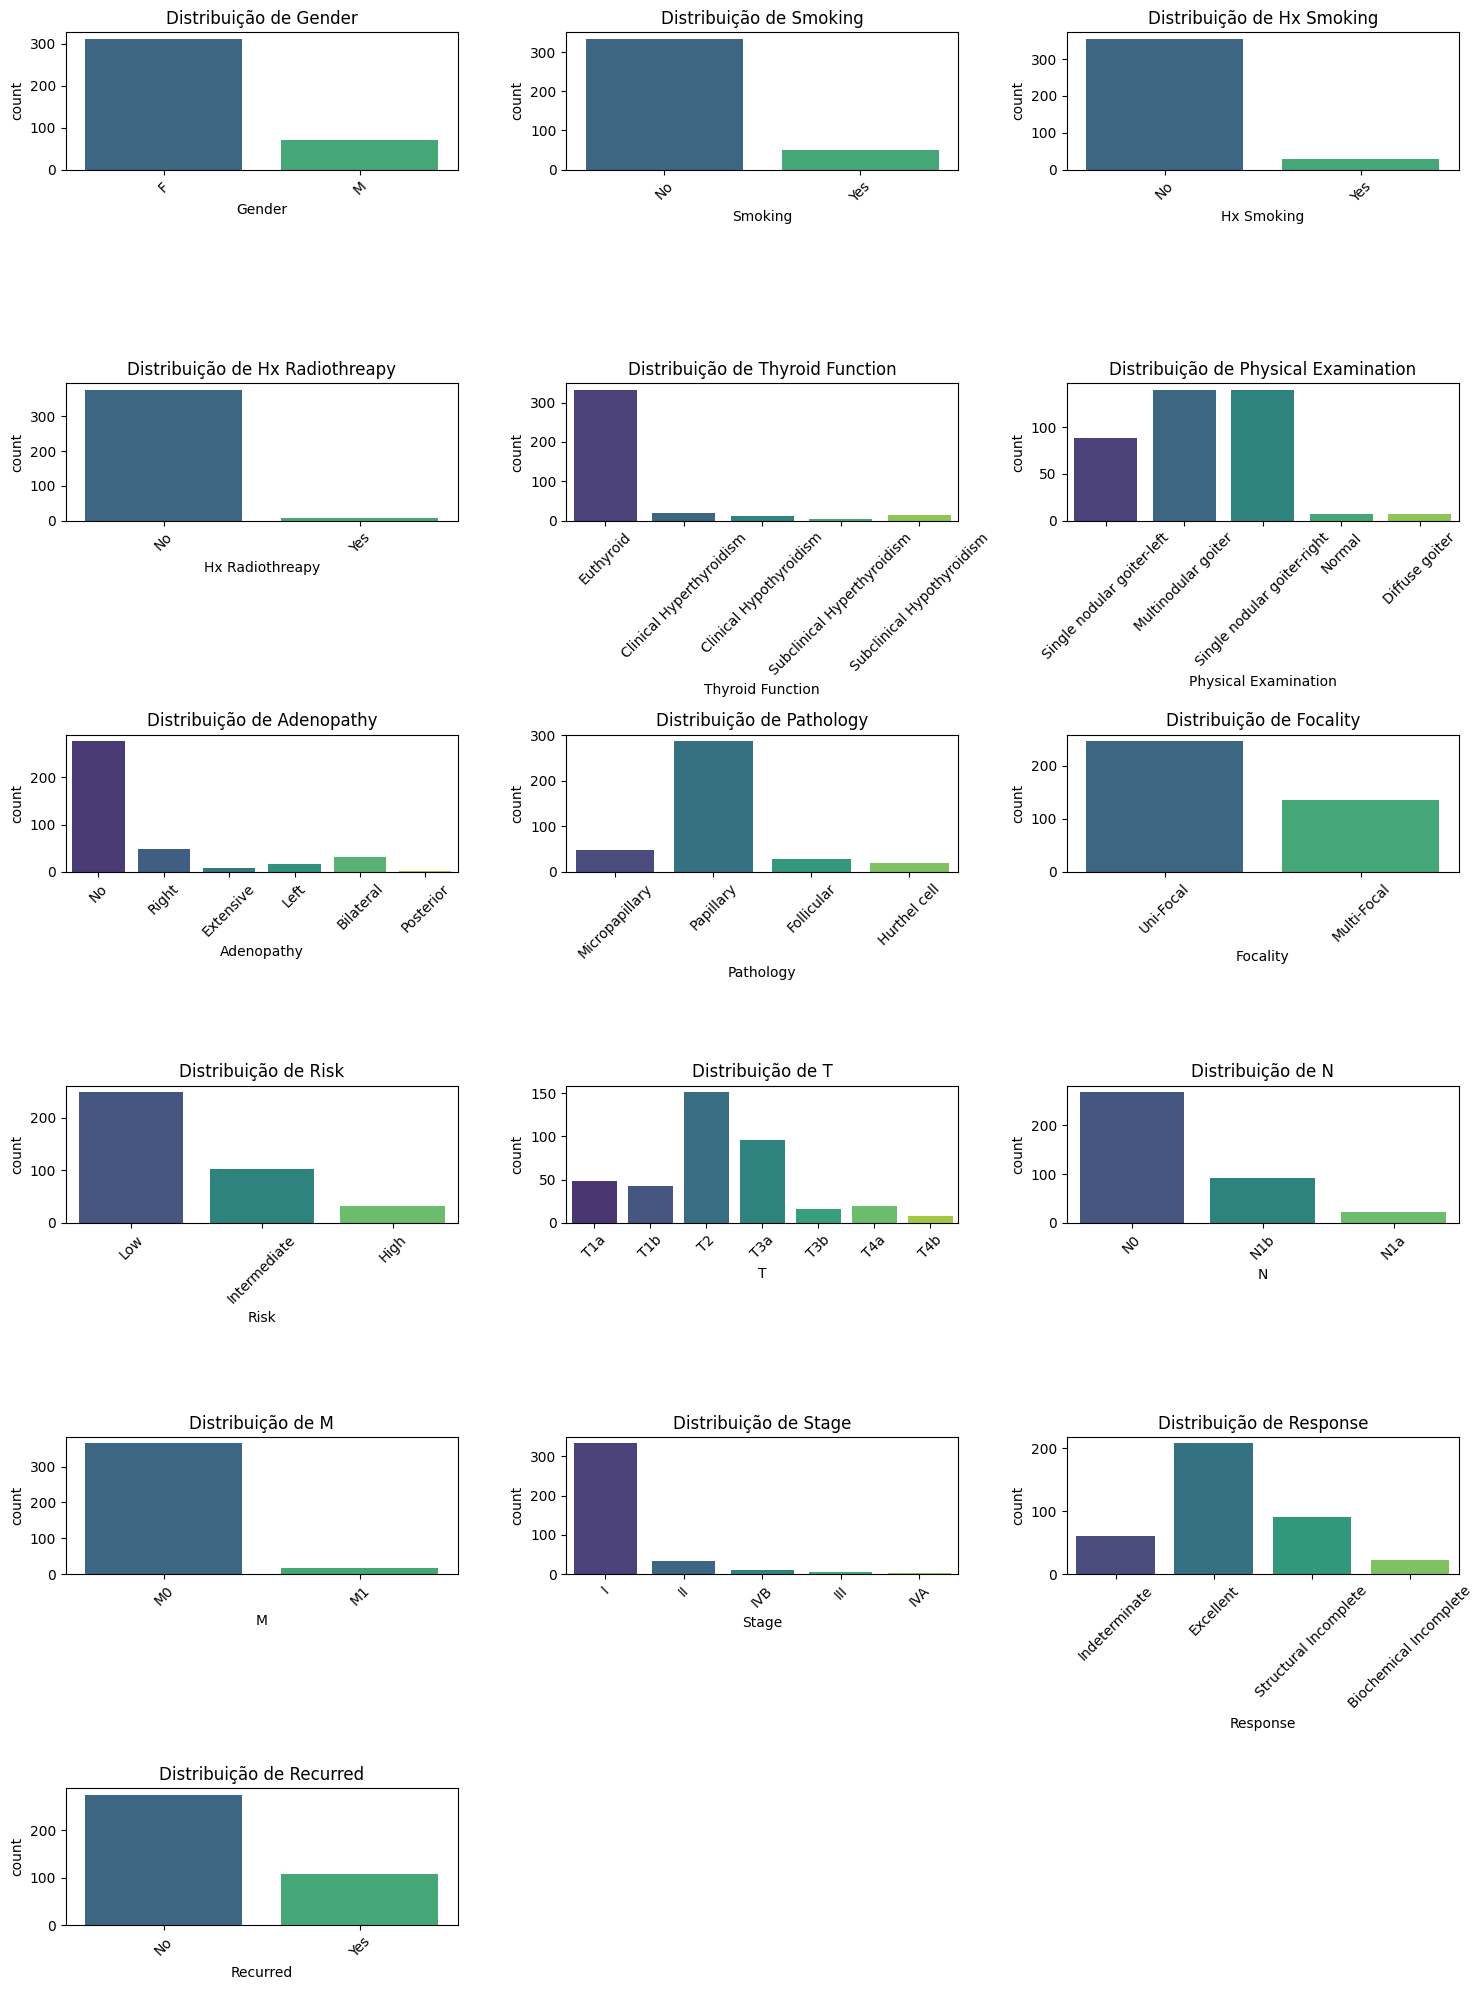

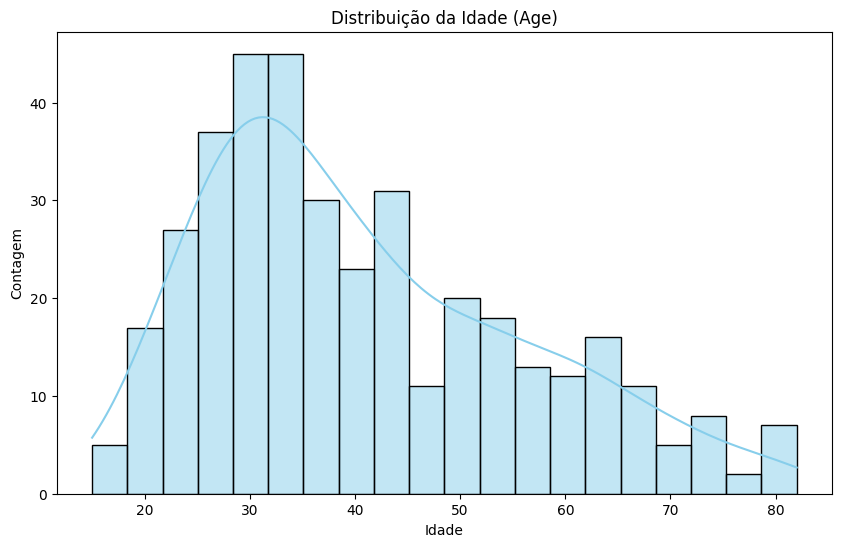

In [ ]:
# Plotar gráficos de barras para variáveis categóricas
plt.figure(figsize=(15, 20))
plt.subplots_adjust(hspace=0.5)

categorical_variables = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function',
                         'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk',
                         'T', 'N', 'M', 'Stage', 'Response', 'Recurred']

for i, var in enumerate(categorical_variables, start=1):
    plt.subplot(6, 3, i)
    sns.countplot(x=var, data=data, palette='viridis')
    plt.title(f'Distribuição de {var}')
    plt.xticks(rotation=45)  # Rotaciona os nomes no eixo x em 45 graus

plt.tight_layout()
plt.show()

# Plotar histograma para a variável contínua 'Age'
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribuição da Idade (Age)')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()


###Pré-Processamento dos Dados

In [ ]:
# Separar a variável alvo e as variáveis preditoras
X = data.drop('Recurred', axis=1)
y = data['Recurred']

In [ ]:
# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Identificar colunas numéricas e categóricas
categorical_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function',
                    'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk',
                    'T', 'N', 'M', 'Stage', 'Response']
numerical_cols = ['Age']

In [ ]:
# Construir o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [ ]:
# Pipeline para pré-processamento e modelo K-NN
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier())])

In [ ]:
# Pipeline para pré-processamento e modelo Árvore de Decisão
pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', DecisionTreeClassifier())])

###Busca de Grade para K-NN

In [ ]:
# Definir os parâmetros para busca de grade do K-NN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

In [ ]:
# Inicializar a busca de grade para K-NN
grid_search_knn = GridSearchCV(estimator=pipeline_knn, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)



In [ ]:
# Treinar o modelo com busca de grade
grid_search_knn.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Gender',
                                                                          'Smoking',
                                                                          'Hx '
                                                                          'Smoking',
                                                                          'Hx '
                                                                          'Radiothreapy',
                                                                          'Thyroid '
                                                                          'Function',
                                                                          'Physical '
                                                                          'Examination',
                                                                          'Adenopathy',
                                                                          'Pathology',
                                                                          'Focality',
                                                                          'Risk',
                                                                          'T',
                                                                          'N',
                                                                          'M',
                                                                          'Stage',
                                                                          'Response'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'manhattan'],
                         'classifier__n_neighbors': [3, 5, 7, 9],
                         'classifier__weights': ['uniform', 'distance']},
             verbose=2)

In [ ]:
# Melhores parâmetros encontrados para K-NN
print("Melhores parâmetros para K-NN:", grid_search_knn.best_params_)

Melhores parâmetros para K-NN: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}


###Busca de Grade para Árvore de Decisão

In [ ]:
# Definir os parâmetros para busca de grade da Árvore de Decisão
param_grid_dt = {
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['auto', 'sqrt', 'log2', None]
}

In [ ]:
# Inicializar a busca de grade para Árvore de Decisão
grid_search_dt = GridSearchCV(estimator=pipeline_dt, param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=2)


In [ ]:
# Treinar o modelo com busca de grade
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Gender',
                                                                          'Smoking',
                                                                          'Hx '
                                                                          'Smoking',
                                                                          'Hx '
                                                                          'Radiothreapy',
                                                                          'Thyroid '
                                                                          'Function',
                                                                          'Physical '
                                                                          'Examination',
                                                                          'Adenopathy',
                                                                          'Pathology',
                                                                          'Focality',
                                                                          'Risk',
                                                                          'T',
                                                                          'N',
                                                                          'M',
                                                                          'Stage',
                                                                          'Response'])])),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10, 15],
                         'classifier__max_features': ['auto', 'sqrt', 'log2',
                                                      None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             verbose=2)

In [ ]:
# Melhores parâmetros encontrados para Árvore de Decisão
print("Melhores parâmetros para Árvore de Decisão:", grid_search_dt.best_params_)

Melhores parâmetros para Árvore de Decisão: {'classifier__max_depth': None, 'classifier__max_features': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}


###Avaliação dos Modelos

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Função para calcular e exibir as métricas
def evaluate_model(model, X_test, y_test):
    # Prever os rótulos do conjunto de teste
    y_pred = model.predict(X_test)

    # Calcular as métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    confusion = confusion_matrix(y_test, y_pred)

    # Exibir as métricas
    print("Acurácia:", accuracy)
    print("Precisão:", precision)
    print("Recall:", recall)
    print("Matriz de Confusão:\n", confusion)

# Avaliar o modelo K-NN
print("Avaliação do modelo K-NN:")
evaluate_model(grid_search_knn, X_test, y_test)

# Avaliar o modelo Árvore de Decisão
print("\nAvaliação do modelo Árvore de Decisão:")
evaluate_model(grid_search_dt, X_test, y_test)


Avaliação do modelo K-NN:
Acurácia: 0.922077922077922
Precisão: 0.9207537560478738
Recall: 0.922077922077922
Matriz de Confusão:
 [[56  2]
 [ 4 15]]

Avaliação do modelo Árvore de Decisão:
Acurácia: 0.987012987012987
Precisão: 0.9872331058771736
Recall: 0.987012987012987
Matriz de Confusão:
 [[58  0]
 [ 1 18]]


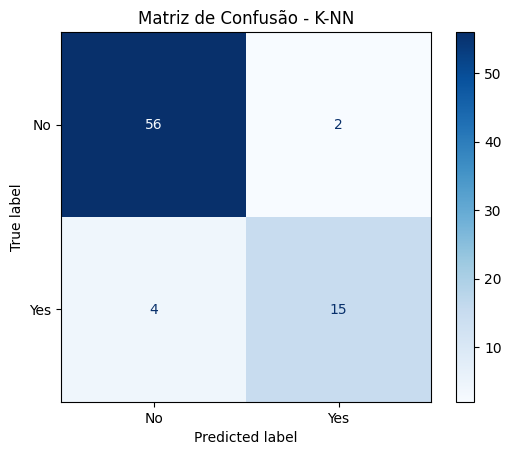

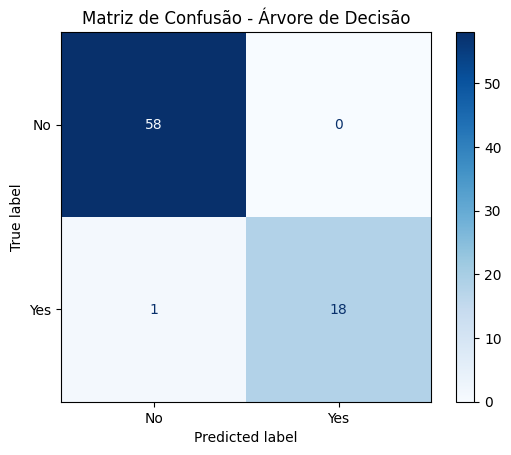

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plotar matriz de confusão para o modelo K-NN
ConfusionMatrixDisplay.from_estimator(grid_search_knn, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusão - K-NN')
plt.show()

# Plotar matriz de confusão para o modelo Árvore de Decisão
ConfusionMatrixDisplay.from_estimator(grid_search_dt, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()


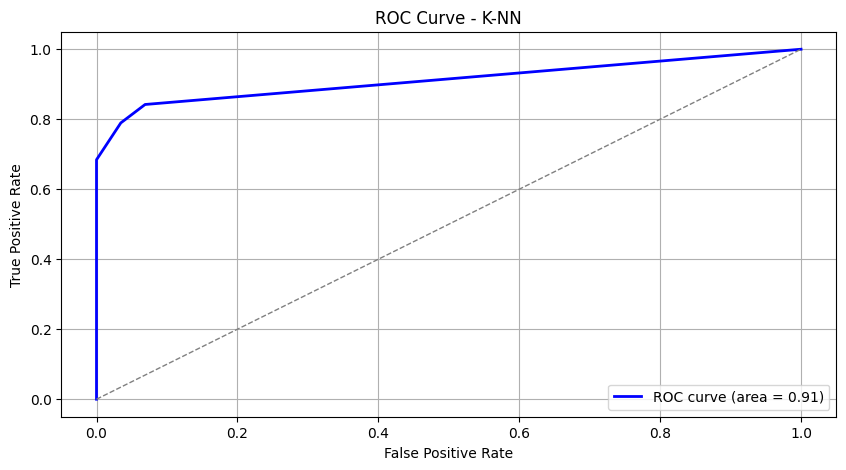

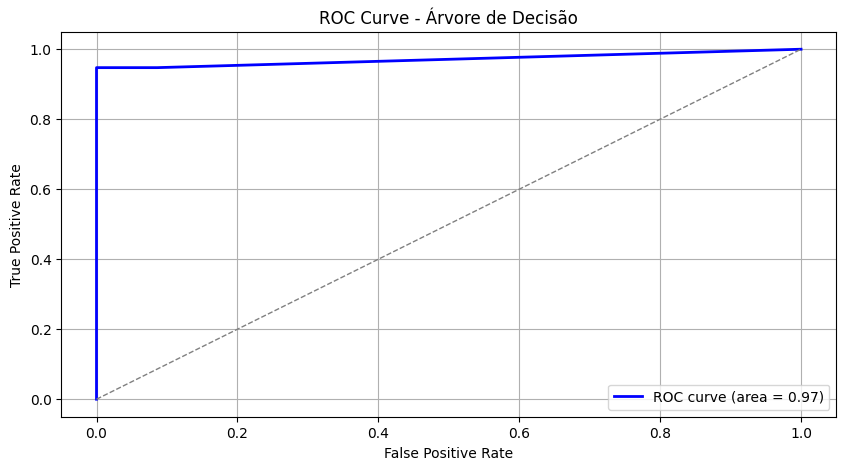

In [ ]:
# Função para plotar curva ROC manualmente com rótulos 'No' e 'Yes'
def plot_roc_curve_manual(model, X_test, y_test, model_name):
    # Mapear rótulos 'No' e 'Yes' para valores binários
    y_test_binary = y_test.map({'No': 0, 'Yes': 1})

    # Calcular as probabilidades previstas
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calcular a curva ROC
    fpr, tpr, _ = roc_curve(y_test_binary, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plotar a curva ROC
    plt.figure(figsize=(10, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - ' + model_name)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


# Plotar curva ROC para o modelo K-NN
plot_roc_curve_manual(grid_search_knn, X_test, y_test, 'K-NN')


# Plotar curva ROC para o modelo Árvore de Decisão
plot_roc_curve_manual(grid_search_dt, X_test, y_test, 'Árvore de Decisão')

